In [ ]:
import os
import numpy as np
import scipy.special as sp
from   scipy.constants import c, h, lambda2nu, nu2lambda
import matplotlib.pyplot as plt

#!pip install OptiCommPy
from optic.utils import parameters
from optic.dsp.core import firFilter, signal_power, pulseShape, upsample, pnorm
from optic.models.devices import mzm, photodiode
from optic.plot import eyediagram

In [ ]:
from IPython.core.display import HTML
from IPython.core.pylabtools import figsize
import matplotlib as mpl

figsize(17, 3.2)
mpl.rcParams['agg.path.chunksize'] = 10000

## Amplificador fibra dopada com érbio - EDFA
---

## Sumário
---
- [Introdução](#introdução)
- [Topologias de amplificadores](#topologias_de_amplificadores)
- [Ruído do amplificador](#Ruído_do_amplificador)
- [Transmissão 10G OOK - 40 km](#transmissão_10G_OOK_-_40_km)

### Introdução
---
Os amplificadores ópticos que utilizam terras raras são fundamentais em sistemas de comunicações ópticas de longa distância, especialmente pela capacidade de amplificar sinais diretamente na forma óptica, sem a necessidade de conversão para o domínio elétrico. Nessa família de elementos químicos, estão presentes o érbio (Er) (1530–1565 nm), praseodímio (Pr) e itérbio (Yb), utilizados na dopagem de núcleos de fibras ópticas. Esses elementos são usados porque possuem níveis de energia específicos que permitem emissão estimulada eficiente na faixa das comunicações ópticas, ou seja, entre 1260 nm e 1625 nm.

O EDFA opera na banda C (1530–1565 nm), banda mais usada em redes ópticas. O PDFA opera na banda O (1260–1360 nm), menos comum, mas importante em certas aplicações. O ganho (gain) e absorção (perda) variam com o comprimento de onda, dependendo da fibra dopada usada.

<center><img src="https://github.com/edsonportosilva/OpticalCommunications/blob/main/jupyter%20notebooks/figuras/edfa_topology.png?raw=true" width="70%"/></center>
<center>Fonte: GitHub Edson Porto</center>

Acima temos uma representação de como é o processo de amplificação óptica usando EDFA, que será demostrado abaixo.

  1. Você tem um sinal óptico fraco $(ωₛ)$ que deseja amplificar.

  2. Um sinal de bombeio $(ωₚ)$ com potência maior é injetado na mesma fibra dopada com érbio (Er³⁺), geralmente com comprimento de onda de 980 nm ou 1480 nm.

  3. A energia do bombeio excita os íons de érbio, promovendo inversão de população — ou seja, os íons ficam em estado excitado.

  4. Quando o sinal $ωₛ$ passa por essa região dopada, ele estimula os íons excitados a decaírem, liberando fótons idênticos ao sinal — mesma fase, frequência e direção.

  5. O sinal cresce em potência, pois vários fótons com a mesma informação original são gerados — esse é o fenômeno de emissão estimulada (o mesmo que ocorre em lasers).

  6. Um filtro na saída remove o resíduo do bombeio $(ωₚ)$, e sobra apenas o sinal amplificado $ωₛ$.

Saving gilesR37003AE.dat to gilesR37003AE (2).dat
Saving giles_MP980.dat to giles_MP980 (2).dat


Text(0.5, 0.98, 'OFS RightWave EDF MP980')

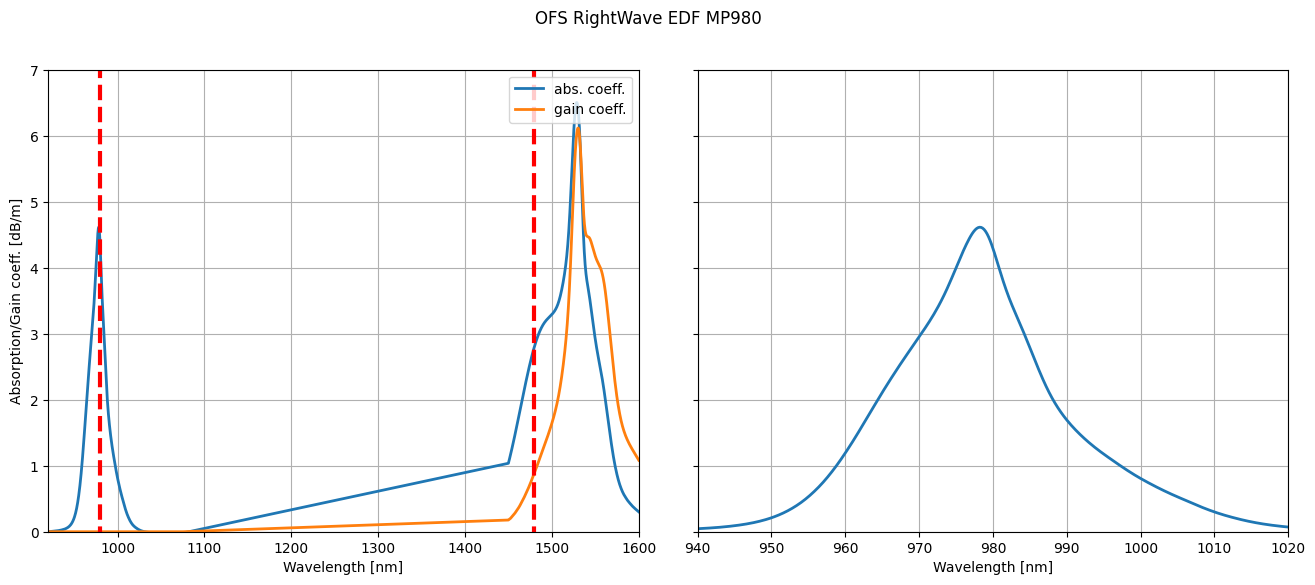

In [ ]:
from google.colab import files
uploaded = files.upload()
dataEDF = dict()
dataEDF["MP980"]  = np.genfromtxt("/content/giles_MP980.dat")

fig, ax = plt.subplots(1, 2, sharey=True, figsize=(20,4))
fig.subplots_adjust(wspace=0.1)

ax[0].plot(dataEDF["MP980"][:,0],
            dataEDF["MP980"][:,1],
            linewidth = 2,
            label = "abs. coeff.")
ax[0].plot(dataEDF["MP980"][:,0],
            dataEDF["MP980"][:,2],
            linewidth = 2,
            label = "gain coeff.")
ax[0].plot([980,980], [-1,8], "r--", linewidth = 3)
ax[0].plot([1480,1480], [-1,8], "r--", linewidth = 3)
ax[0].set_xlabel("Wavelength [nm]")
ax[0].set_ylabel("Absorption/Gain coeff. [dB/m]")
ax[0].set_xlim([920,1600])
ax[0].set_ylim([0,7])
ax[0].legend(loc = "upper right")
ax[0].grid(True)

ax[1].plot(dataEDF["MP980"][:,0],
            dataEDF["MP980"][:,1],
            linewidth = 2)
ax[1].set_xlabel("Wavelength [nm]")
ax[1].set_xlim([940,1020])
ax[1].grid(True)

fig.suptitle("OFS RightWave EDF MP980")

###Topologias de amplificadores
---

Há três formas de realizar o bombeio em um EDFA:

  - Bombeio copropagante;
  - Bombeio contrapropagante;
  - Bombeio bidirecional.

No bombeio copropagante, o sinal incidente propaga-se na mesma direção do bombeio, simples de implementar, boa para baixa potência. Na situação contra-propagante, o sinal incidente propaga-se na direção oposta do sinal de bombeio, maior eficiência no regime saturado, menor ruído ASE. No regime de saturação, a eficiência de conservação de potência é, em geral, melhor na configuração contrapropagante.

Na configuração de bombeamento bidirecional, um EDFA é bombeado de modo simultâneo nos dois sentidos, com o uso de dois lasers, cada um localizado em uma extremidade da fibra. Melhor desempenho, mas mais complexo, apresenta a vantagem de uma inversão de população e, portanto, ganho de pequeno sinal
<center><img src = "https://github.com/edsonportosilva/OpticalCommunications/blob/main/jupyter%20notebooks/figuras/edfa_topology_forward.png?raw=true" width="40%"/>
<img src = https://github.com/edsonportosilva/OpticalCommunications/blob/main/jupyter%20notebooks/figuras/edfa_topology_forward.png?raw=true" width="40%"/></center>
<center><img src = "https://github.com/edsonportosilva/OpticalCommunications/blob/main/jupyter%20notebooks/figuras/edfa_topology_bidirectional.png?raw=true" width="70%"/></center>
<center>Fonte: GitHub Edson Porto</center>

O sinal de bombeio pode ser inserido no mesmo sentido (copropagante) ou no sentido oposto (contrapropagante) ao do sinal óptico a ser amplificado. No modo copropagante, a amplificação ocorre mais rapidamente, pois o bombeio excita os íons desde o início da fibra. No modo contrapropagante, a amplificação é iniciada mais tardiamente ao longo da fibra, já que o bombeio vem de trás e excita os íons conforme avança.

Em ambos os casos, a amplificação do sinal óptico ocorre ao longo da fibra dopada com érbio, e não de forma instantânea. Essa amplificação depende do processo físico de inversão de população nos átomos de érbio excitados pelo sinal de bombeio, o sinal de dados, ao passar por esse meio, é amplificado devido à transferência de energia dos íons excitados. Os isoladores permitem que a luz passe em um único sentido, evitam reflexões indesejadas dentro da fibra

### Ruído do amplificador

A extensão da degradação é quantificada pela figura de ruído _(noise figure)_ do amplificador, definida como:

$$\begin{equation}
F_n = \frac{OSNR_{in}}{OSNR_{out}} ⟶
F_n = 2n_{sp}\left(1 - \frac{1}{G}\right) + \frac{1}{G}
\end{equation}$$

em que $G$ é o ganho linear do amplificador e  $n_{sp}$  o fator de emissão espontânea (ou fator de inversão de população. Por fim, a densidade espectral do ruído de emissão espontânea amplificada (ASE) é escrita como:

$$\begin{equation}
S_{sp}(f_c) = (G - 1)n_{sp}hf_c
\end{equation}$$
### Transmissão 10G OOK - 40 km

In [ ]:
def SSF_symmetric(E, hz, Lspan, alpha, gamma, D, Fc, Fs):
    λ  = c/Fc
    α  = 1e-3*alpha/(10*np.log10(np.exp(1)))
    β2 = -(D*λ**2)/(2*np.pi*c)

    Nfft = len(E)

    ω = 2*np.pi*Fs*np.fft.fftfreq(Nfft)
    z = 0

    E = np.fft.fft(E)

    while z <= Lspan:
        # Primeiro passo - operador linear
        E = E*np.exp(-α*(hz/2)+1j*(β2/2)*(ω**2)*(hz/2))

        # Operador não linear
        E = np.fft.ifft(E)
        E = E*np.exp(1j*gamma*(np.abs(E)**2)*hz)

        # Segundo passo - operador linear
        E = np.fft.fft(E)
        E = E*np.exp(-α*(hz/2)+1j*(β2/2)*(ω**2)*(hz/2))

        z = z + hz

    E = np.fft.ifft(E)
    return E,z

def edfa_lin(signal, gain, nf, fc, fs):
    nf_lin   = 10**(nf/10)
    gain_lin = 10**(gain/10)
    nsp      = (gain_lin*nf_lin - 1)/(2*(gain_lin - 1))
    s_ase    = (gain_lin - 1) * nsp * h * fc
    p_noise  = s_ase * fs
    mean_noise = 0
    noise    = np.random.normal(mean_noise, np.sqrt(p_noise), signal.shape) + 1j*np.random.normal(mean_noise, np.sqrt(p_noise), signal.shape)
    return signal*gain_lin + noise

In [ ]:
# parâmetros da simulação
SpS = 32
Rs  = 10e9          # Taxa de símbolos (para o caso do OOK Rs = Rb)
Ts  = 1/Rs          # Período de símbolo em segundos
Fa  = 1/(Ts/SpS)    # Frequência de amostragem do sinal (amostras/segundo)
Ta  = 1/Fa          # Período de amostragem

# Parâmetros do sinal
lmbd   = 1550e-9       # comprimento de onda
Pi_dBm = 3             # potência de sinal óptico na entrada do modulador em dBm
Fc     = lambda2nu(lmbd)

# Parâmetros da fibra
alpha = 0.16   # dB/Km
D     = 18e-6  # Parâmetro de dispersão s/(m*m) - SMF28 (ps/(nm*km))
gamma = 1.3e-3 # W-1/m
Lspan = 40e3   # Comprimento do enlace m
hz    = 0.1e3  # m

# Parâmetros do receptor
Rd  = 0.85      # responsividade em A/W

NameError: name 'lambda2nu' is not defined

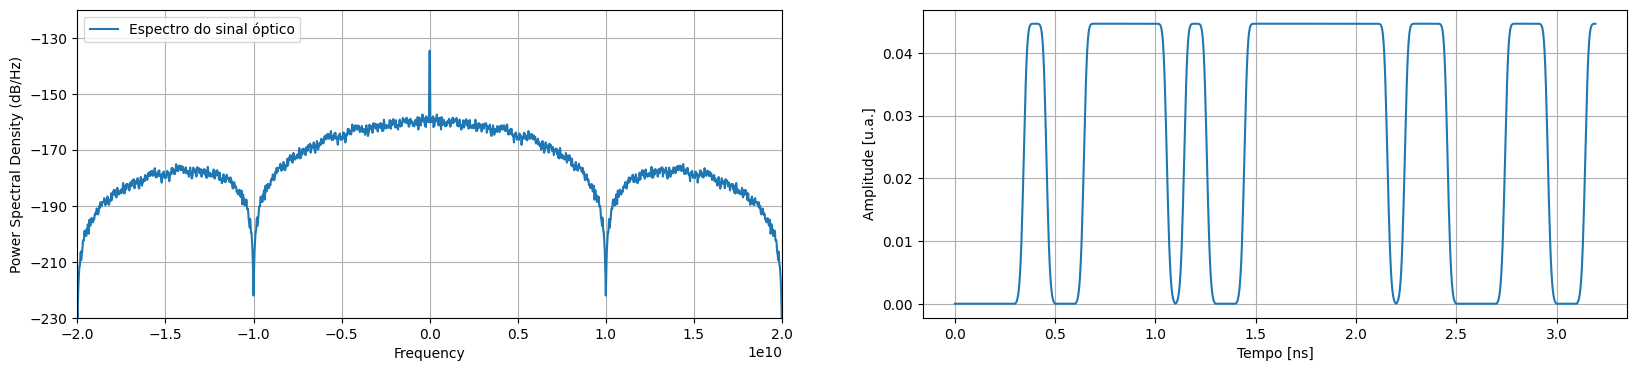

In [ ]:
# Parâmetros do MZM
paramMZM = parameters()
paramMZM.Vpi = 2
paramMZM.Vb = (-paramMZM.Vpi/2)
Pi =  10**(Pi_dBm/10)*1e-3

# gera sequência de bits pseudo-aleatórios
bits   = np.random.randint(2, size=10000)
n      = np.arange(0, bits.size)

# mapeia bits para pulsos elétricos
symbTx = 2*bits-1
symbTx = symbTx/np.sqrt(signal_power(symbTx))

# upsampling
symbolsUp = upsample(symbTx, SpS)

# pulso NRZ típico
pulse = pulseShape('nrz', SpS)
pulse = pulse/max(abs(pulse))

# plota sinal
t = np.arange(0, symbTx.size)*(Ta/1e-9)

#idX = np.arange(0,513)
idX = np.arange(0,1023)

# formatação de pulso
sigTx  = firFilter(pulse, symbolsUp)

# modulação óptica
Ai     = np.sqrt(Pi)
sigTxo = mzm(Ai, -(paramMZM.Vb)*sigTx, paramMZM)

# plota psd
fig, axs = plt.subplots(1, 2, figsize=(20,4))
axs[0].set_xlim(-2*Rs,2*Rs);
axs[0].set_ylim(-230,-120);
axs[0].psd(np.abs(sigTxo)**2,Fs=Fa, NFFT = 16*1024, sides='twosided', label = 'Espectro do sinal óptico')
axs[0].legend(loc='upper left')

axs[1].plot(t[idX], np.abs(sigTxo[idX]))
axs[1].set_xlabel('Tempo [ns]')
axs[1].set_ylabel('Amplitude [u.a.]')
axs[1].grid(True)

Potência do sinal Tx (em dBm) = 0.04 dBm
Potência do sinal Rx (em dBm) = 0.05 dBm


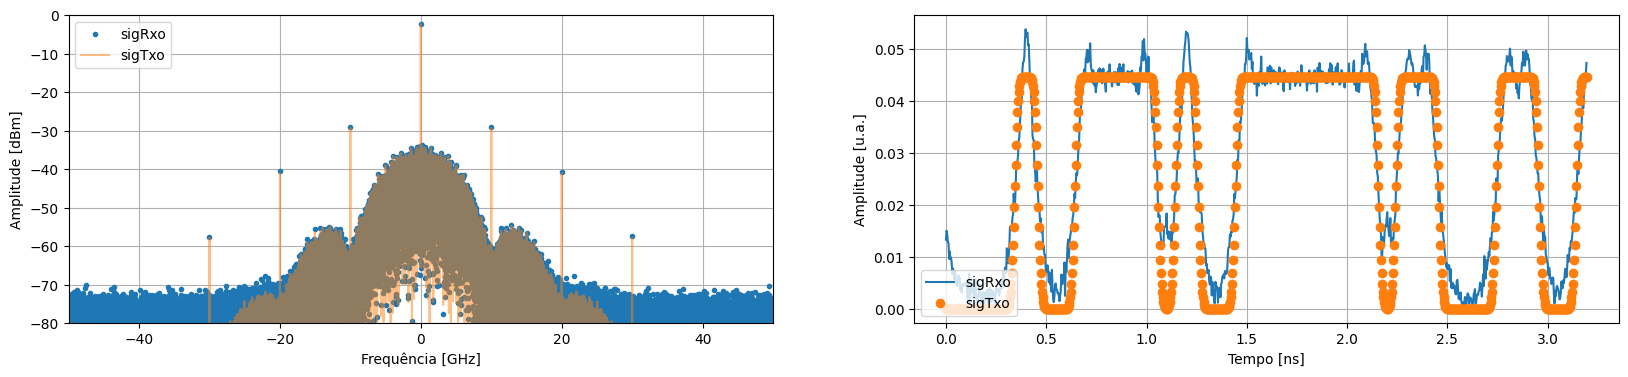

In [ ]:
# transmissão óptica
NFFT = len(sigTxo)
sigTxoFFT = np.fft.fftshift(np.fft.fft(sigTxo))/NFFT
sigTxoPx  = np.abs(sigTxoFFT)**2
freq = np.fft.fftshift(np.fft.fftfreq(len(sigTxoFFT), Ta))

# Fibra óptica
sigRxo, z = SSF_symmetric(sigTxo, hz, Lspan, alpha, gamma, D, Fc, Fa) # Propagation

#alpha_lin = 1e-3*alpha/(10*np.log10(np.exp(1)))
#sigRxo    = sigRxo*np.exp(alpha_lin * z)                             # Amplification
sigRxo    = edfa_lin(sigRxo, 1e-3*alpha*z, 12, Fc, Fa)

sigRxoFFT = np.fft.fftshift(np.fft.fft(sigRxo))/NFFT
sigRxoPx  = np.abs(sigRxoFFT)**2

fig, axs = plt.subplots(1, 2, figsize=(20,4))
axs[0].plot(1e-9*freq, 10*np.log10(1e3*sigRxoPx), '.', label = 'sigRxo')
axs[0].plot(1e-9*freq, 10*np.log10(1e3*sigTxoPx), alpha = 0.5, label = 'sigTxo')
axs[0].set_ylabel('Amplitude [dBm]')
axs[0].set_xlabel('Frequência [GHz]')
axs[0].set_xlim(-5e-9*Rs,5e-9*Rs)
axs[0].set_ylim(-80,0)
axs[0].grid(True)
axs[0].legend(loc = 'upper left')

axs[1].plot(t[0:1023], np.abs(sigRxo[0:1023]), label = 'sigRxo')
axs[1].plot(t[0:1023], np.abs(sigTxo[0:1023]), 'o', label = 'sigTxo')
axs[1].set_xlabel('Tempo [ns]')
axs[1].set_ylabel('Amplitude [u.a.]')
axs[1].grid(True)
axs[1].legend(loc = 'lower left')

print('Potência do sinal Tx (em dBm) = %.2f dBm' %(10*np.log10(np.sum(sigTxoPx)/1e-3)))
print('Potência do sinal Rx (em dBm) = %.2f dBm' %(10*np.log10(np.sum(sigRxoPx)/1e-3)))

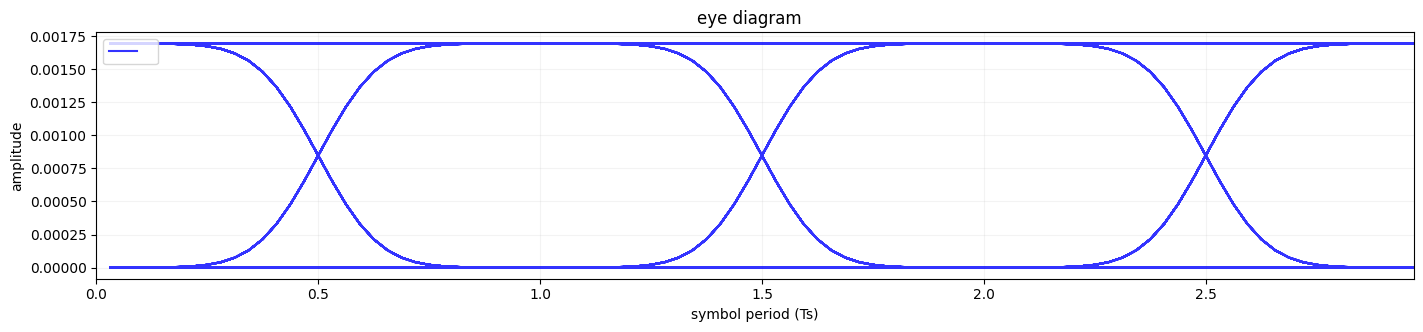

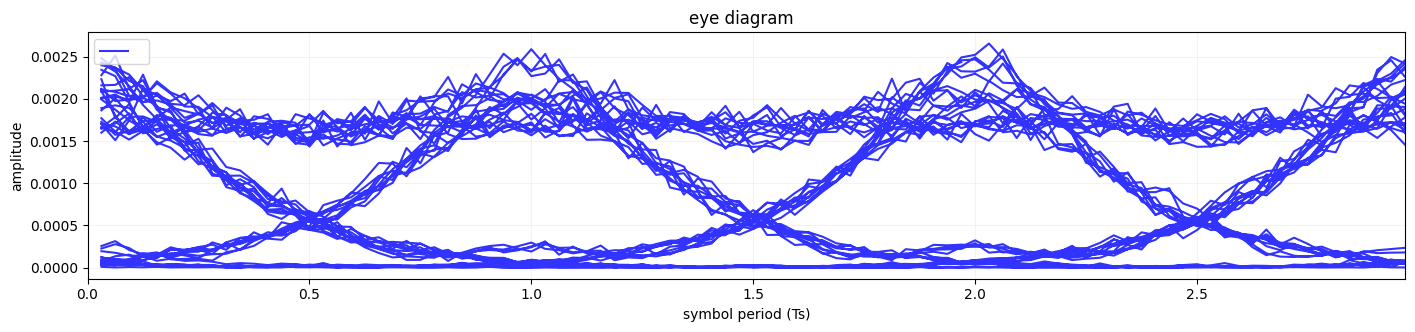

In [ ]:
# Recepção do sinal óptico
Nsamples = 2**12

# fotocorrente livre de ruído
Ip   = Rd*np.abs(sigTxo)**2
I_Rx = Rd*np.abs(sigRxo)**2

# diagrama de olho
eyediagram(Ip,  Nsamples, SpS)
eyediagram(I_Rx, Nsamples, SpS)

A função edfa_lin() retorna um sinal óptico amplificado com a adição de ruído ASE (Amplified Spontaneous Emission), o principal ruído gerado pelos amplificadores ópticos (como EDFA).

Explicação dos parametros da função:
``edfa_lin(sigRxo, 1e-3*alpha*z, 12, Fc, Fa)``

Parâmetro | Significado
:------: | :------: |
sigRxo | O sinal óptico recebido da fibra após propagação com dispersão e perdas.
1e-3 * alpha * z | O ganho necessário (em dB) para compensar as perdas da fibra ao longo do comprimento z (ver explicação anterior).
12 | Figura de ruído (NF) do amplificador, em dB. É um parâmetro típico de EDFA.
Fc | Frequência central óptica do sinal (Hz), usada para calcular a densidade espectral de ruído: ``S(ν) = (G-1) * nsp * h * Fc``
Fa | Frequência de amostragem (Hz), necessária para transformar densidade espectral de ruído em potência total no tempo discreto.